<h1>Decision Tree Terminology</h1>

- **Root Node**: the initial node at the beginning of a decision tree, where the entire population or datasets starts deviding on various features and conditions, and this root node will be determined mathematically to choose.

- **Decision Node**: are the brances Nodes stems from the Root Node, despite having the same row, but less impact. Nodes resulting from the spliting of the root nodes are known as decision nodes. These nodes represents intermediate decisions within the tree

- **Leaf Nodes**: Nodes where further splitting is not possible, which is basically the outcomes. Often considered as terminal nodes

- **Sub-Tree**: Similar to a subsection of a graph -> sub-graph, a sub-section of these tree is referred as sub-tree, represents a specific portion of the decision tree, like the dicision node has its sub-tree for instance.

- **Pruning**: the process of removing or cutting down specific nodes in a tree to prevent overfitting the model

- **Branch/Sub-Tree**: A subsection of the entire thing is reffered to as branch or sub-tree, represents a specific path of decisions and outcomes within the tree

- **Parent and Child Nodes**: In a decision tree, a node that is devided into subnodes is know as a parents node, and the sub-nodes emerging from it are referred as child nodes. The parent node represent a decision or condition, while the child nodes represnets the potential outcomes or futher decisions based on that conditions.

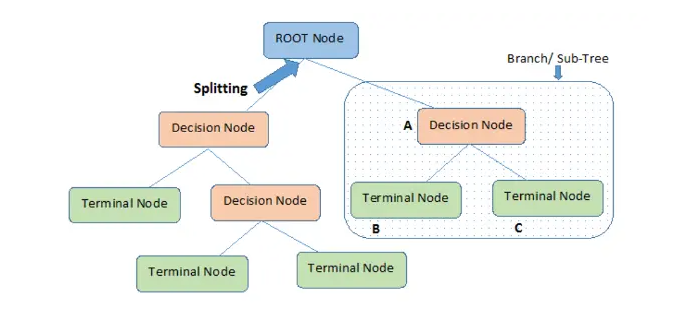

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

weather_df = pd.read_excel("/home/ducanh19082007/Quantitative_Finance_Self_Learning/Data/0.Data_Sets/weather_data.xlsx")
weather_df

,Day,Weather,Temperature,Humidity,Wind,Play?
0,1,Sunny,Hot,High,Weak,No
1,2,Cloudy,Hot,High,Weak,Yes
2,3,Sunny,Mild,Normal,Strong,Yes
3,4,Cloudy,Mild,High,Strong,Yes
4,5,Rainy,Mild,High,Strong,No
5,6,Rainy,Cool,Normal,Strong,No
6,7,Rainy,Mild,High,Weak,Yes
7,8,Sunny,Hot,High,Strong,No
8,9,Cloudy,Hot,Normal,Weak,Yes
9,10,Rainy,Mild,High,Strong,No




<h3> Entropy Function for Decision Tree </h3>

We use the **entropy function** to evaluate the purity of the splitting method.

- The higher the value of the entropy function, the **more impurity** of the splitting method.  
- The lower the value of the entropy function, the **more purity** of the splitting method.

We have a discrete variable $x$ which can be one of $n$ values $x_1, x_2, \ldots, x_n$.  
We have the probability of $x = x_i$ is $p_i$ such that: ($0 \le p_i \le 1, \sum_{i=1}^n p_i = 1$) So we have: $\mathbf{p = (p_1, p_2, \dots, p_n)}$

The entropy function is defined as:

$$
H(p) = - \sum_{i=1}^{n} p_i \log_2(p_i) \tag{1}
$$

> If $n = 2$ (means x can be one of 2 values)

**Note**: The logarithm is base 2.

-> basically, after this calculation, the smaller one will be choosen for its purity.


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_107684/1793752931.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.title("$H(p) = -p\log_2(p) - (1-p)\log_2 (1-p)$",size = 25)
/tmp/ipykernel_107684/1793752931.py:4: RuntimeWarning: divide by zero encountered in log2
  return - p*np.log2(p) - (1-p)*np.log2(1-p)
/tmp/ipykernel_107684/1793752931.py:4: RuntimeWarning: invalid value encountered in scalar multiply
  return - p*np.log2(p) - (1-p)*np.log2(1-p)


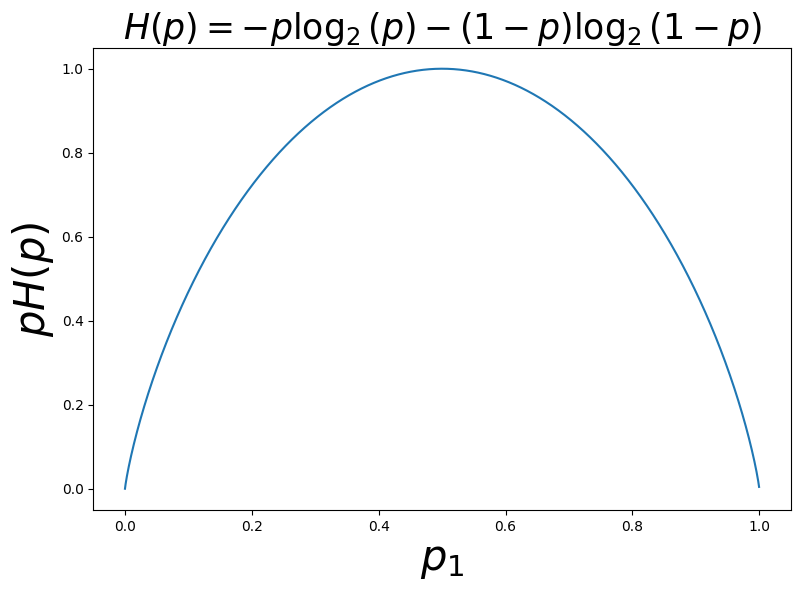

In [30]:
def entropy (p):
    if p == 0:
        return 0
    return - p*np.log2(p) - (1-p)*np.log2(1-p)

x = np.linspace(0,1,3000)
y = list(map(entropy,x))
plt.figure(figsize=(9,6))
plt.plot(x,y)
plt.title("$H(p) = -p\log_2(p) - (1-p)\log_2 (1-p)$",size = 25)
plt.xlabel('$p_1$',size = 30)
plt.ylabel('$pH(p)$',size = 30)
plt.show()

In [31]:
class_1_num_br_no = 0
total_br_yes_1 = 3
H_br_no = entropy(class_1_num_br_no/total_br_yes_1)
print(H_br_no)

class_2_num_br_no = 1
total_br_no_2 = 4
H_br_no = entropy(class_2_num_br_no/total_br_no_2)
print(H_br_no)

class_3_num_br_no = 1
total_br_no_3 = 3
H_br_no = entropy(class_3_num_br_no/total_br_no_3)
print(H_br_no)

0
0.8112781244591328
0.9182958340544896


In [32]:
weather_df.groupby(by=["Weather"]).agg({"Play?":list})

,Play?
Weather,
Cloudy,"[Yes, Yes, Yes]"
Rainy,"[No, No, Yes, No]"
Sunny,"[No, Yes, No]"


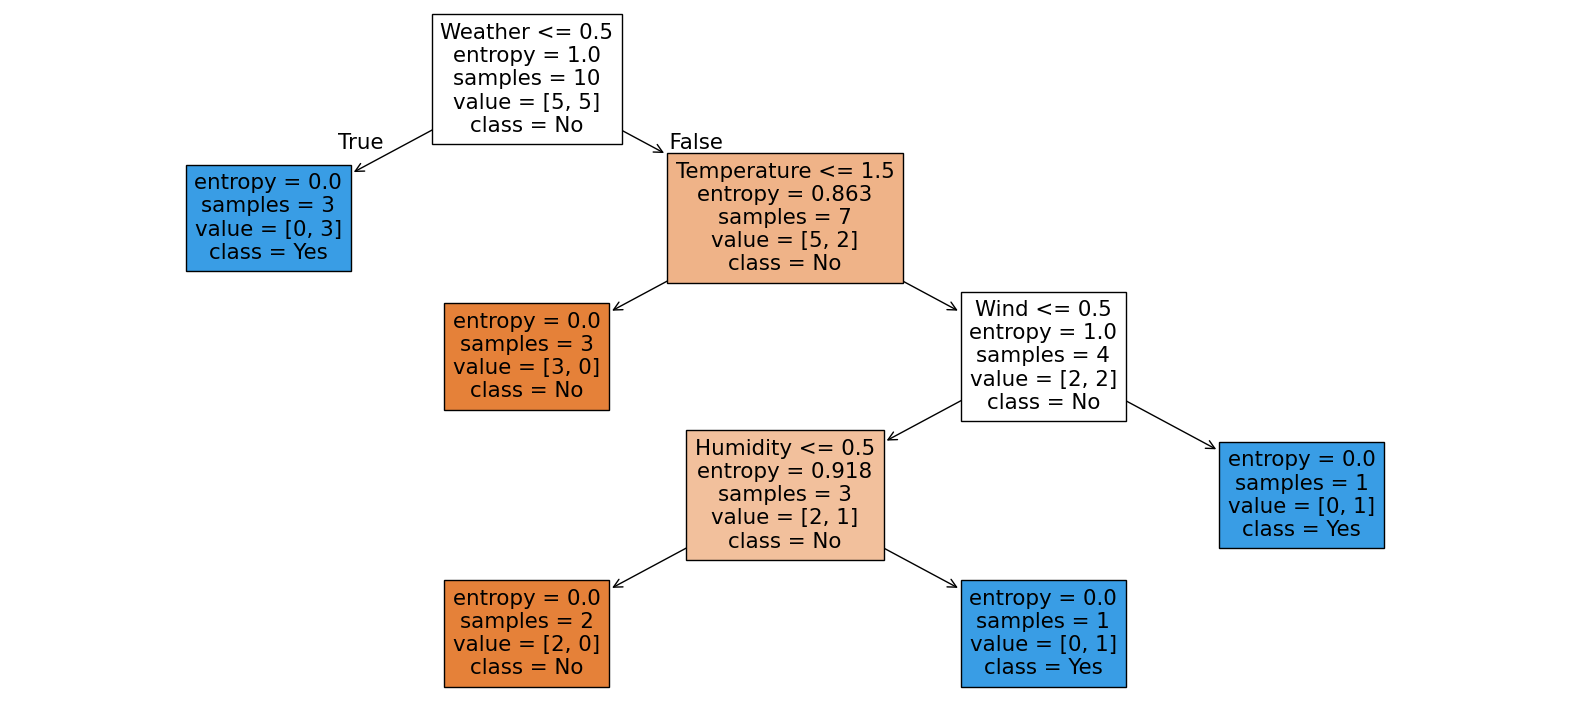

'\nlet discuss the plot_tree in detail\n\nFor short, this would obvious create this magnificient (i think) tree plot, but what all these stuff actually\nmeans?\n\nFirst of all, we have to give it the model with the integrated data inside it first\nfor the informations that it need to gain\n\nSecond of all, the feature_name parameters will be the one that gains the name of each\nnodes, or each rows from the datasets, which this have to an array like, and thus the\nx.columns will do all that\n\nThird of all, the filled, when set to True, paint nodes to indicate majority class\nfor classification (colors), extremity of values for regression, or purity of node\nfor multi-output. This basically reponsible to all the letters available in each nodes\n\nLast of all, the class_name which will dictate the output, if its = 0 then will pronounce\nthe first one, and = 1 then will pronounce the second one\n'

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Prepare the data
x = weather_df.iloc[:, 1:-1]
y = weather_df["Play?"]

from sklearn.preprocessing import LabelEncoder
labelencoderer = LabelEncoder()
y = labelencoderer.fit_transform(y)
for i in x:
  x[i] = labelencoderer.fit_transform(x[i])

DecisionTreeClassifier_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
DecisionTreeClassifier_model.fit(x, y)

plt.figure(figsize=(20, 9))
plot_tree(decision_tree = DecisionTreeClassifier_model,
          feature_names=list(x.columns),
          filled=True,
          class_names=["No", "Yes"])
plt.show()


'''
let discuss the plot_tree in detail

For short, this would obvious create this magnificient (i think) tree plot, but what all these stuff actually
means?

First of all, we have to give it the model with the integrated data inside it first
for the informations that it need to gain

Second of all, the feature_name parameters will be the one that gains the name of each
nodes, or each rows from the datasets, which this have to an array like, and thus the
x.columns will do all that

Third of all, the filled, when set to True, paint nodes to indicate majority class
for classification (colors), extremity of values for regression, or purity of node
for multi-output. This basically reponsible to all the letters available in each nodes

Last of all, the class_name which will dictate the output, if its = 0 then will pronounce
the first one, and = 1 then will pronounce the second one
'''

# Another Demonstration

In [34]:
cat_df = pd.read_excel("/home/ducanh19082007/Quantitative_Finance_Self_Learning/Data/0.Data_Sets/cat.xlsx")
cat_df

,Ear shape,Face shape,Whiskers,Cat
0,Pointy,Round,Present,1
1,Floppy,Not round,Absent,0
2,Pointy,Round,Absent,1
3,Pointy,Not round,Present,0
4,Floppy,Not round,Absent,0
5,Pointy,Round,Absent,1
6,Pointy,Round,Present,1
7,Floppy,Not round,Present,1
8,Floppy,Round,Absent,0
9,Pointy,Round,Absent,1


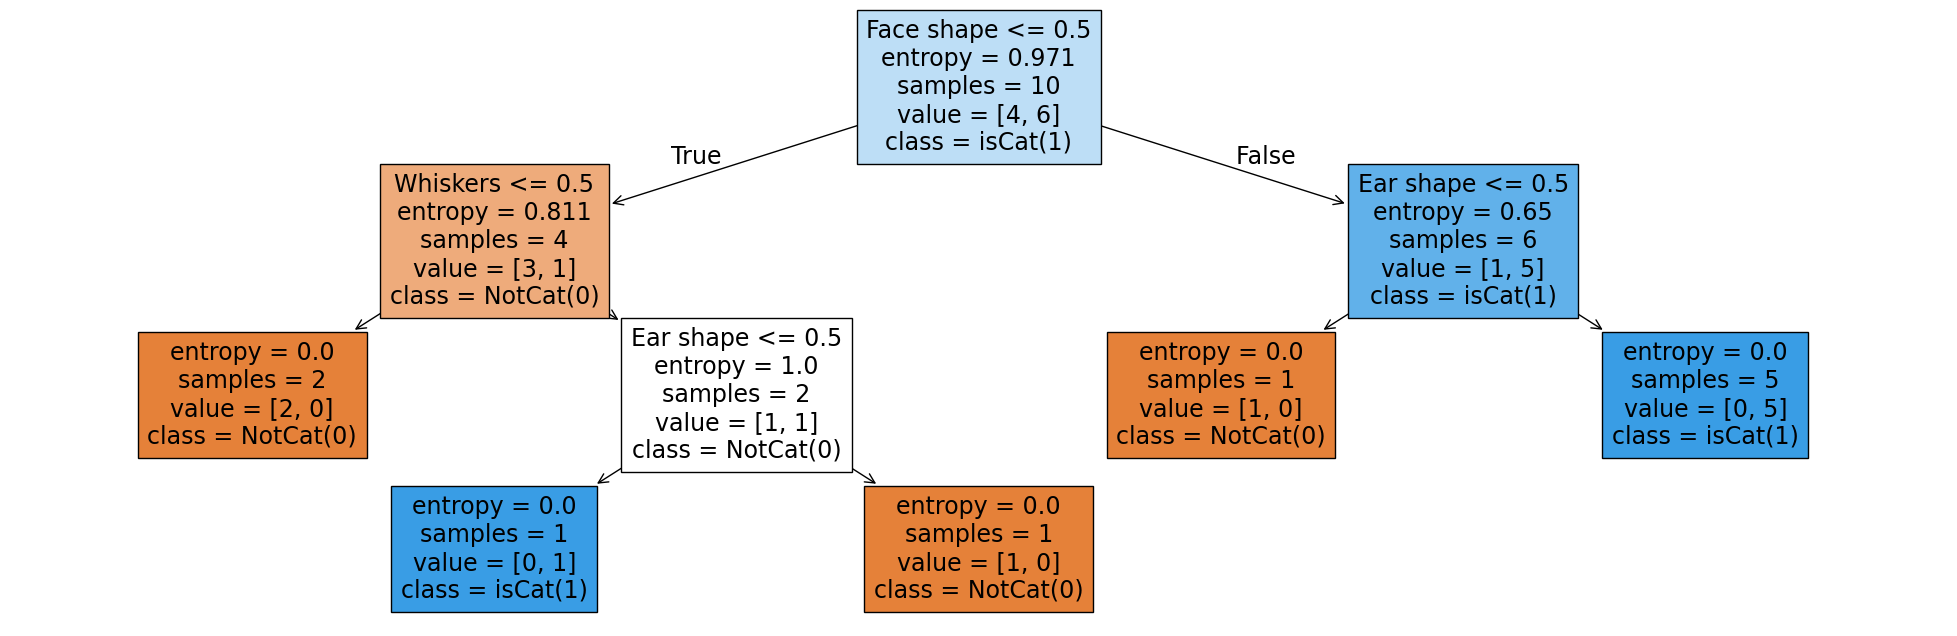

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

x=cat_df.iloc[:,:-1]
y = cat_df["Cat"]

from sklearn.preprocessing import LabelEncoder
labelencoderer = LabelEncoder()
y = labelencoderer.fit_transform(y) #encoding it to 0 and 1, which is the standard for classification problems
for i in x:
  x[i] = labelencoderer.fit_transform(x[i])

DecisionTreeClassifier_model_2 = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
DecisionTreeClassifier_model_2.fit(x,y)
plt.figure(figsize=(25,8))
plot_tree(decision_tree = DecisionTreeClassifier_model_2,
          feature_names=list(x.columns),
          filled=True,
          class_names=["NotCat(0)", "isCat(1)"])
plt.show()

# A More extreme examples

In [36]:
def plot_decision_boundary(model, X, y, title):
    import numpy as np
    import matplotlib.pyplot as plt
    
    h = 0.02  # slightly larger step to avoid memory issues
    
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    
    if X.shape[1] == 1:
        x_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
        y_pred = model.predict(x_grid)
        
        plt.scatter(X[:, 0], y, c=y)
        plt.plot(x_grid, y_pred)
        
        plt.title(title)
        plt.xlabel("X")
        plt.ylabel("Class")
        plt.show()
        
    else:
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, h),
            np.arange(y_min, y_max, h)
        )
        
        grid = np.c_[xx.ravel(), yy.ravel()]
        
        # Predict
        Z = model.predict(grid)
        Z = Z.reshape(xx.shape)
        
        # Plot decision surface
        plt.contourf(xx, yy, Z, alpha=0.3)
        
        # Plot points
        plt.scatter(X[:, 0], X[:, 1], c=y)
        
        plt.title(title)
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.show()

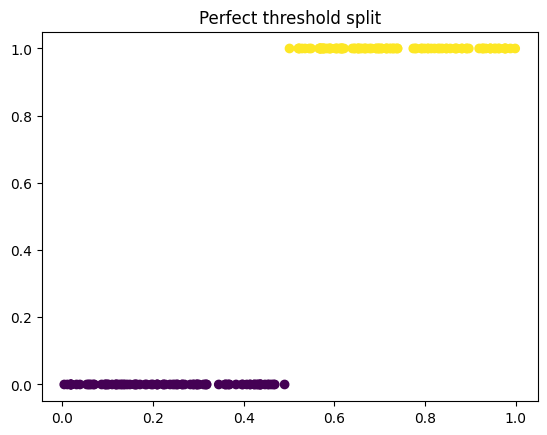

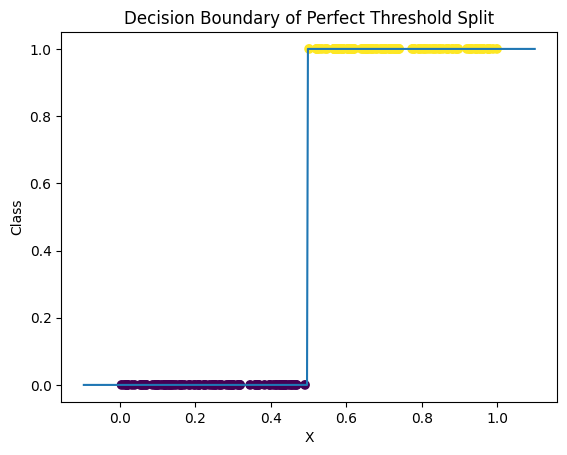

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Generate data
np.random.seed(0)
X = np.random.rand(200, 1)
y = (X[:, 0] > 0.5).astype(int)  # sharp threshold

# Train tree
tree = DecisionTreeClassifier(max_depth=1)
tree.fit(X, y)

# Plot
plt.scatter(X, y, c=y)
plt.title("Perfect threshold split")
plt.show()
plot_decision_boundary(tree, X, y, "Decision Boundary of Perfect Threshold Split")


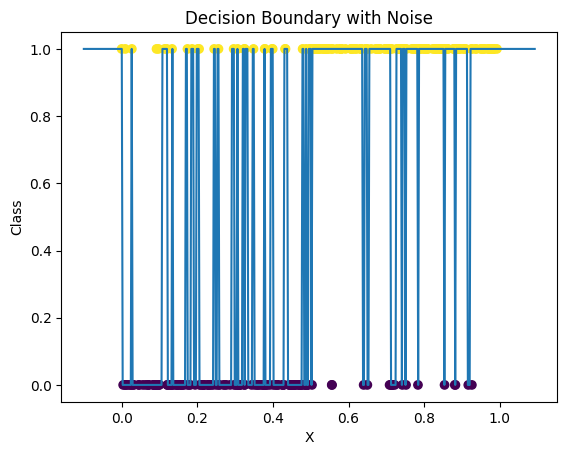

In [38]:
X = np.random.rand(300, 1)
y = (X[:, 0] > 0.5).astype(int)

# Add noise
noise_idx = np.random.choice(len(y), size=50)
y[noise_idx] = 1 - y[noise_idx]

tree = DecisionTreeClassifier(max_depth=None)
tree.fit(X, y)
plot_decision_boundary(tree, X, y, "Decision Boundary with Noise")

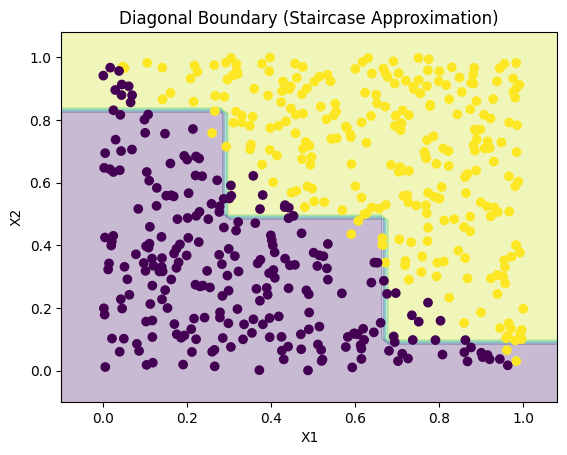

In [39]:
X = np.random.rand(500, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

plot_decision_boundary(tree, X, y, "Diagonal Boundary (Staircase Approximation)")

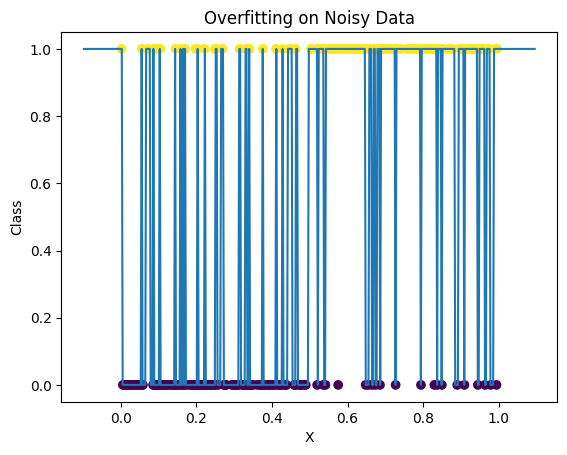

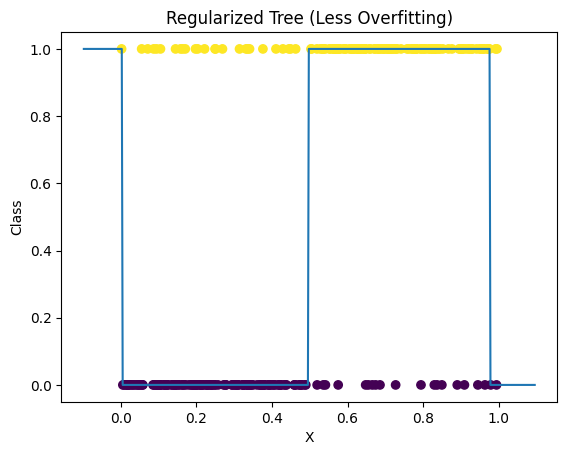

In [44]:
X = np.random.rand(300, 1)
y = (X[:, 0] > 0.5).astype(int)

noise_idx = np.random.choice(len(y), size=50)
y[noise_idx] = 1 - y[noise_idx]

tree = DecisionTreeClassifier(max_depth=None)
tree.fit(X, y)

plot_decision_boundary(tree, X, y, "Overfitting on Noisy Data")

tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X, y)
plot_decision_boundary(tree, X, y, "Regularized Tree (Less Overfitting)")

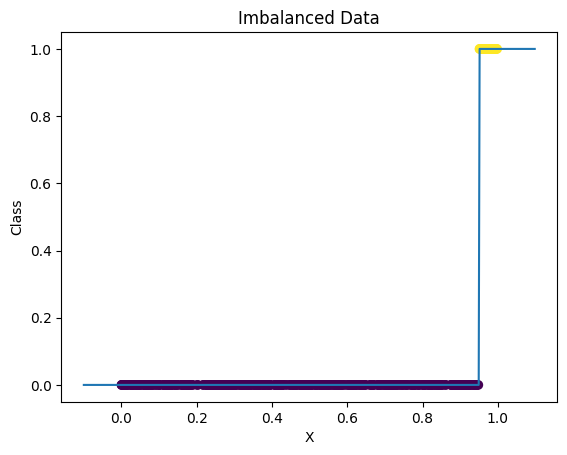

In [41]:
X = np.random.rand(500, 1)
y = (X[:, 0] > 0.95).astype(int)

tree = DecisionTreeClassifier()
tree.fit(X, y)

plot_decision_boundary(tree, X, y, "Imbalanced Data")

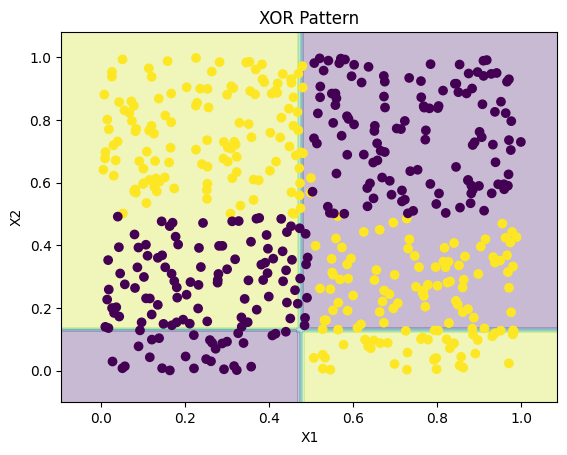

In [42]:
X = np.random.rand(500, 2)
y = ((X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)).astype(int)

tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X, y)

plot_decision_boundary(tree, X, y, "XOR Pattern")

"""lwk the tree is greedy, so it will try to find the best split at each step, which is why it creates a staircase pattern to approximate the diagonal boundary.
The more depth we allow, the closer it can get to the true diagonal, but it will never be perfect due to the nature of axis-aligned splits.

for this one, the boundaries is a bit off since the tree is trying to find the best splits, 
but it can't perfectly capture the XOR pattern with axis-aligned splits, 
leading to a more complex decision boundary that may not perfectly separate the classes."""

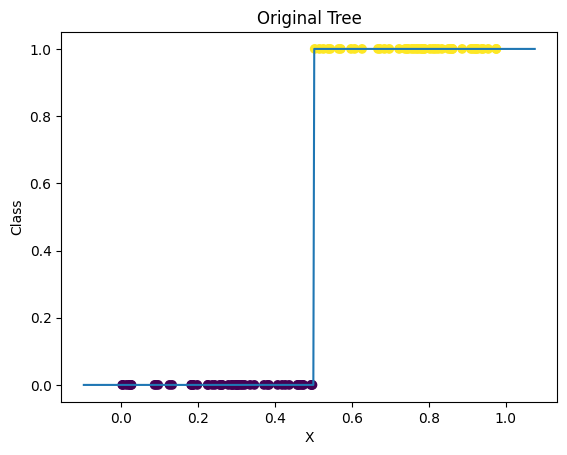

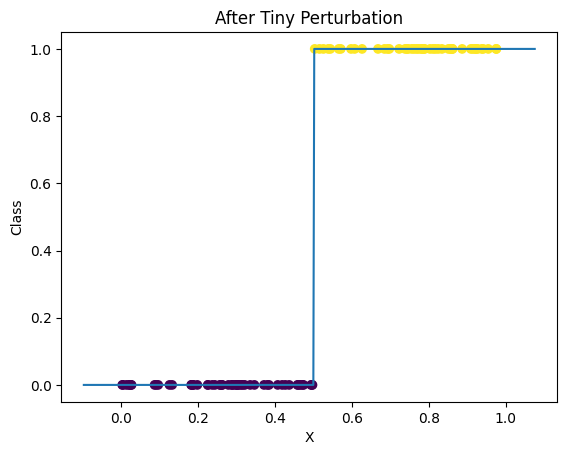

In [43]:
X = np.random.rand(100, 1)
y = (X[:, 0] > 0.5).astype(int)

tree1 = DecisionTreeClassifier().fit(X, y)

# Slight perturbation
X2 = X.copy()
X2[0, 0] += 0.02

tree2 = DecisionTreeClassifier().fit(X2, y)

plot_decision_boundary(tree1, X, y, "Original Tree")
plot_decision_boundary(tree2, X2, y, "After Tiny Perturbation")